# Big Title

## Initialization

### Imports

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.optimize import curve_fit
from pathlib import Path

import scienceplots
plt.style.use(['science', 'grid'])

from TherMIFASOL.core.variables.GlobalVariables import (
    spectral_range_monochromatic_camera, LAMBDA_NIR, FWHM_NIR, QE_NIR,
    pyrometer_channel_1, pyrometer_channel_2,
)
from TherMIFASOL.core.models.ThermalLaws import (
    planck_law, wien_law, wien_law_equivalent,
    wien_law_gaussian, wien_law_equivalent_gaussian
)

### Globals Variables

In [2]:
T_low = 500 + 273.15
T_high = 1300 + 273.15
array_working_temperature_range = np.arange(T_low, T_high)

## Coefficient search

### CRED2Lite

#### Numerical integral part

In [3]:
fluxIntegral_CRED2Lite = []
for T in array_working_temperature_range:
    fluxIntegral_CRED2Lite.append(integrate.quad(
        lambda l: wien_law(l, T), 
        spectral_range_monochromatic_camera[0], 
        spectral_range_monochromatic_camera[1])[0]
    )
fluxIntegral_CRED2Lite = np.asarray(fluxIntegral_CRED2Lite)

#### Equivalent part

In [4]:
popt, pcov = curve_fit(
    f=wien_law_equivalent, 
    xdata=array_working_temperature_range, 
    ydata=fluxIntegral_CRED2Lite, 
    bounds=(
        (-np.inf, spectral_range_monochromatic_camera[0]), 
        (np.inf, spectral_range_monochromatic_camera[1]))
    )

perr = np.sqrt(np.diag(pcov))
print("Optimized parameters:")
print(f"over CRED2Lite spectral range: {spectral_range_monochromatic_camera[0]*1e6} µm and {spectral_range_monochromatic_camera[1]*1e6} µm")
for i, (p, err) in enumerate(zip(popt, perr)):
    print(f"  param {i+1}: {p:.4e} ± {err:.4e}")

Optimized parameters:
over CRED2Lite spectral range: 1.1 µm and 1.7 µm
  param 1: 5.5514e-07 ± 2.2396e-10
  param 2: 1.4317e-06 ± 3.1170e-10


#### Plot results

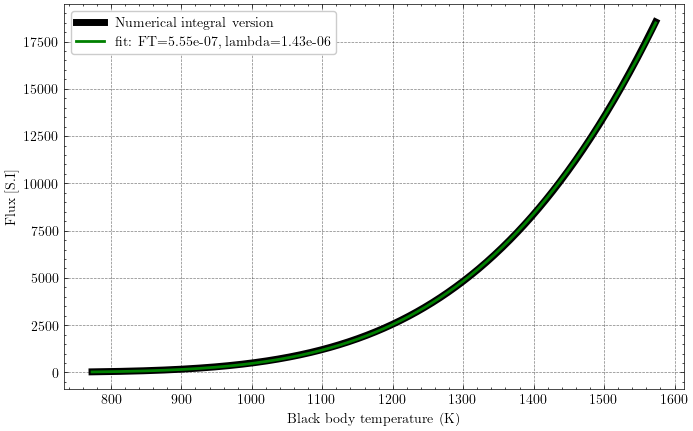

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(
    array_working_temperature_range, fluxIntegral_CRED2Lite, 
    c='k', lw=5, label='Numerical integral version'
    )
plt.plot(
    array_working_temperature_range, wien_law_equivalent(array_working_temperature_range, *popt), 
    c='g', lw=2, label=f'fit: FT={popt[0]:.2e}, lambda={popt[1]:.2e}'
    )
plt.xlabel('Black body temperature (K)')
plt.ylabel('Flux [S.I]')
plt.legend()
plt.grid(True)
plt.show()

#### Planck's law vs Wien equivalent's law

In [6]:
array_planck_CRED2Lite = np.zeros(len(array_working_temperature_range))
array_wien_CRED2Lite = np.zeros(len(array_working_temperature_range))
array_wien_equivalent_CRED2Lite = np.zeros(len(array_working_temperature_range))

for i, T in enumerate(array_working_temperature_range):
    array_planck_CRED2Lite[i] = integrate.quad(
        lambda l: planck_law(l, T), spectral_range_monochromatic_camera[0], spectral_range_monochromatic_camera[1])[0]
    array_wien_CRED2Lite[i] = integrate.quad(
        lambda l: wien_law(l, T), spectral_range_monochromatic_camera[0], spectral_range_monochromatic_camera[1])[0]
array_wien_equivalent_CRED2Lite = wien_law_equivalent(array_working_temperature_range, *popt)

- $\xi_1(T) = \frac{|\varPhi_{\text{w,num}}(T) - \varPhi_{\text{p,num}}(T)|}{\varPhi_{\text{p,num}}(T)} \times 100$

- $\xi_2(T) = \frac{|\varPhi_{\text{w,eq}}(T) - \varPhi_{\text{p,num}}(T)|}{\varPhi_{\text{p,num}}(T)} \times 100$

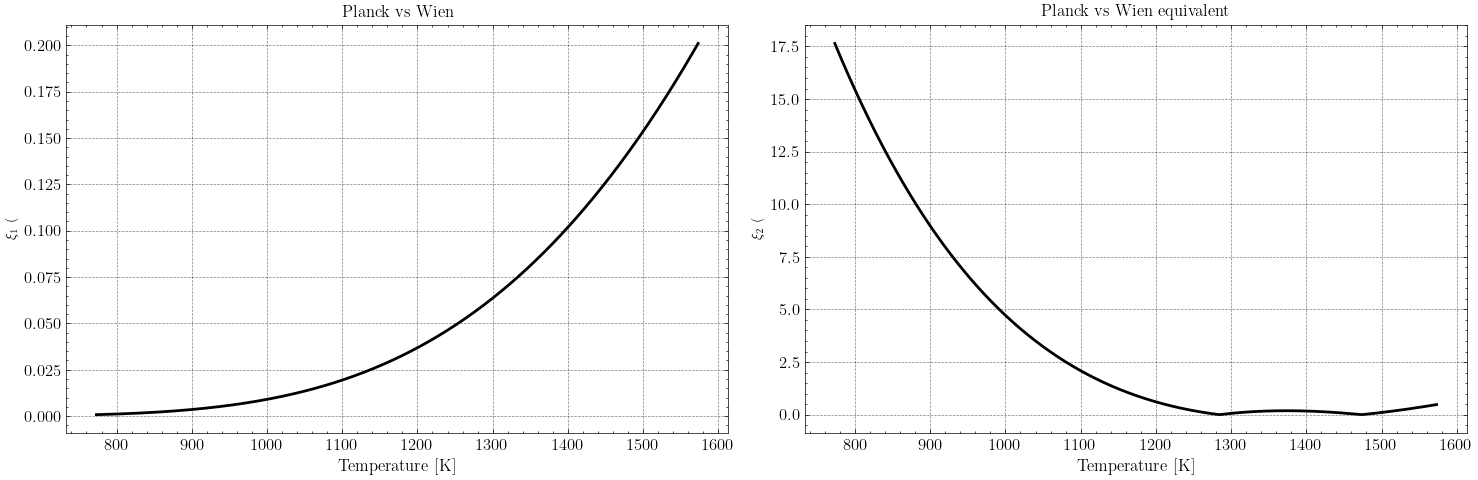

In [7]:
error_CRED2Lite = 100*np.abs(array_planck_CRED2Lite - array_wien_CRED2Lite)/array_planck_CRED2Lite
error_eq_CRED2Lite = 100*np.abs(array_planck_CRED2Lite - array_wien_equivalent_CRED2Lite)/array_planck_CRED2Lite  # %


fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 5), sharex=True)

## First graph: Wien vs Planck
ax1.plot(
    array_working_temperature_range, error_CRED2Lite, 
    c='k', lw=2
    )
ax1.set_xlabel("Temperature [K]", fontsize=12)
ax1.set_ylabel(r"$\xi_1$ (%)")
ax1.set_title("Planck vs Wien")
# ax1.legend(loc='best', fontsize=12, frameon=True, shadow=True)
ax1.tick_params(axis='both', labelsize=12)
ax1.grid(True)

## Second graph: Wien equivalent vs Planck
ax2.plot(
    array_working_temperature_range, error_eq_CRED2Lite, 
    c='k', lw=2
    )
ax2.set_xlabel("Temperature [K]", fontsize=12)
ax2.set_ylabel(r"$\xi_2$ (%)")
ax2.set_title("Planck vs Wien equivalent")
# ax2.legend(loc='best', fontsize=12, frameon=True, shadow=True)
ax2.tick_params(axis='both', labelsize=12)
ax2.grid(True)

fig.tight_layout()
plt.show()

### Ximea

In [8]:
keq_array = []
lambda_eq_array = []
error_array = []

for I_max, fwhm_m, lambda_center_m in zip(QE_NIR, FWHM_NIR, LAMBDA_NIR):

    # Define integration bounds: +/- 3 sigma
    lambda_low = lambda_center_m - 3 * fwhm_m
    lambda_high = lambda_center_m + 3 * fwhm_m
    lambda_eq = (lambda_low + lambda_high) / 2  # Central equivalent wavelength

    # Integrate flux for each temperature
    flux_integrated = []
    for T in array_working_temperature_range:
        result, _ = integrate.quad(
            lambda l: wien_law_gaussian(
                wavelength=l,
                temperature=T,
                I_max=I_max, 
                fwhm=fwhm_m, 
                center_wavelength=lambda_center_m
                ),
            lambda_low, lambda_high
        )
        flux_integrated.append(result)
    flux_integrated = np.asarray(flux_integrated)

    # Fit equivalent Wien-like model: only Keq is optimized
    popt, pcov = curve_fit(
        f=lambda T, Keq: wien_law_equivalent_gaussian(
            temperature=T,
            FT_equivalent=Keq,
            wavelength_eq=lambda_eq,
            I_max=I_max,
            fwhm=fwhm_m,
            center_wavelength=lambda_center_m
        ),
        xdata=array_working_temperature_range,
        ydata=flux_integrated,
        bounds=(0, np.inf)
    )

    Keq_opt = popt[0]
    keq_array.append(Keq_opt)
    lambda_eq_array.append(lambda_eq)

    # Evaluate error between model and integrated flux
    model_flux = wien_law_equivalent_gaussian(
        temperature=array_working_temperature_range,
        FT_equivalent=Keq_opt,
        wavelength_eq=lambda_eq,
        I_max=I_max,
        fwhm=fwhm_m,
        center_wavelength=lambda_center_m
    )

    rel_error = np.mean(np.abs((flux_integrated - model_flux) / flux_integrated))
    error_array.append(rel_error)

# Convert to arrays
keq_array = np.array(keq_array)
lambda_eq_array = np.array(lambda_eq_array)
error_array = np.array(error_array)

In [9]:
for lamb, keq, err in zip(lambda_eq_array, keq_array, error_array):
    print(f"λ_eq = {lamb:.4e} nm | Keq = {keq:.4e} | Error = {err:.2%}")

λ_eq = 9.1148e-07 nm | Keq = 1.6325e-08 | Error = 0.13%
λ_eq = 9.1990e-07 nm | Keq = 1.9495e-08 | Error = 0.18%
λ_eq = 9.2933e-07 nm | Keq = 1.9495e-08 | Error = 0.17%
λ_eq = 9.3940e-07 nm | Keq = 2.0683e-08 | Error = 0.19%
λ_eq = 9.4925e-07 nm | Keq = 1.8502e-08 | Error = 0.14%
λ_eq = 8.5180e-07 nm | Keq = 1.0780e-08 | Error = 0.08%
λ_eq = 8.6297e-07 nm | Keq = 1.1175e-08 | Error = 0.08%
λ_eq = 8.7745e-07 nm | Keq = 1.3354e-08 | Error = 0.11%
λ_eq = 8.8910e-07 nm | Keq = 1.4146e-08 | Error = 0.11%
λ_eq = 8.9808e-07 nm | Keq = 1.5137e-08 | Error = 0.12%
λ_eq = 7.8758e-07 nm | Keq = 7.6114e-09 | Error = 0.06%
λ_eq = 8.0328e-07 nm | Keq = 7.6112e-09 | Error = 0.05%
λ_eq = 8.1332e-07 nm | Keq = 8.6014e-09 | Error = 0.06%
λ_eq = 8.2632e-07 nm | Keq = 8.9973e-09 | Error = 0.07%
λ_eq = 8.4179e-07 nm | Keq = 1.0780e-08 | Error = 0.09%
λ_eq = 7.2774e-07 nm | Keq = 7.6125e-09 | Error = 0.08%
λ_eq = 7.3854e-07 nm | Keq = 8.6031e-09 | Error = 0.10%
λ_eq = 7.5185e-07 nm | Keq = 7.2158e-09 | Error 

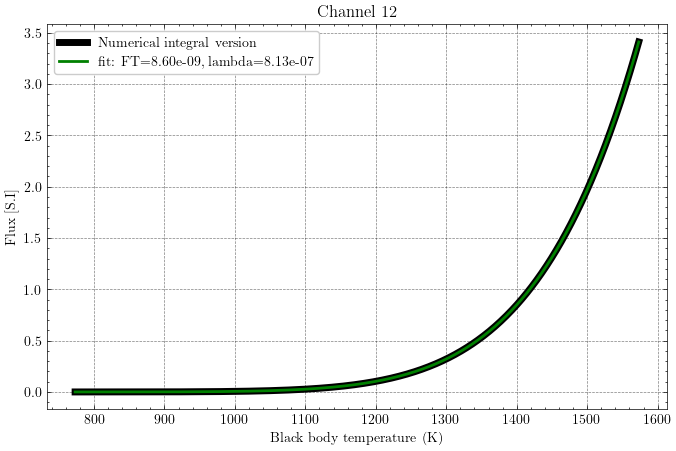

In [10]:
canal=12
Imax, FWHM, lamb_m = QE_NIR[canal], FWHM_NIR[canal], LAMBDA_NIR[canal]
Keq_opt, lamb_eq = keq_array[canal], lambda_eq_array[canal]
low_born = (lamb_m - 3*FWHM)
high_born = (lamb_m + 3*FWHM)

fluxIntegral_XIMEA = []
for T in array_working_temperature_range:
    fluxIntegral_XIMEA.append(integrate.quad(
        lambda l: wien_law_gaussian(l, T, Imax, FWHM, lamb_m), low_born, high_born
        )[0])
fluxIntegral_XIMEA = np.asarray(fluxIntegral_XIMEA)
fluxEquivalent_XIMEA = wien_law_equivalent_gaussian(array_working_temperature_range, Keq_opt, lamb_eq, Imax, FWHM, lamb_m)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    array_working_temperature_range, fluxIntegral_XIMEA, 
    c='k', lw=5, label='Numerical integral version'
    )
ax.plot(
    array_working_temperature_range, fluxEquivalent_XIMEA, 
    c='g', lw=2, label=f'fit: FT={Keq_opt:.2e}, lambda={lamb_eq:.2e}'
    )

plt.title(f"Channel {canal}")
plt.xlabel('Black body temperature (K)')
plt.ylabel('Flux [S.I]')
plt.legend()
plt.grid(True)
plt.show()

### Pyrometer

#### Numerical integral part

In [11]:
fluxIntegral_PYROMETER_ch1 = []
fluxIntegral_PYROMETER_ch2 = []

for T in array_working_temperature_range:
    fluxIntegral_PYROMETER_ch1.append(integrate.quad(
        lambda l: wien_law(l, T), pyrometer_channel_1[0], pyrometer_channel_1[1])[0]
    )
    fluxIntegral_PYROMETER_ch2.append(integrate.quad(
        lambda l: wien_law(l, T), pyrometer_channel_2[0], pyrometer_channel_2[1])[0]
    )

fluxIntegral_PYROMETER_ch1 = np.asarray(fluxIntegral_PYROMETER_ch1)
fluxIntegral_PYROMETER_ch2 = np.asarray(fluxIntegral_PYROMETER_ch2)

#### Equivalent part

In [12]:
popt_1, pcov_1 = curve_fit(
    f=wien_law_equivalent, 
    xdata=array_working_temperature_range, 
    ydata=fluxIntegral_PYROMETER_ch1, 
    bounds=(
        (-np.inf, pyrometer_channel_1[0]), 
        (np.inf, pyrometer_channel_1[1]))
    )
perr_1 = np.sqrt(np.diag(pcov_1))

popt_2, pcov_2 = curve_fit(
    f=wien_law_equivalent, 
    xdata=array_working_temperature_range, 
    ydata=fluxIntegral_PYROMETER_ch2, 
    bounds=(
        (-np.inf, pyrometer_channel_2[0]), 
        (np.inf, pyrometer_channel_2[1]))
    )
perr_2 = np.sqrt(np.diag(pcov_2))

print("Optimized parameters over Pyrometer spectral range:")
print(f"\tChannel 1 : {pyrometer_channel_1[0]*1e6:.2f} µm and {pyrometer_channel_1[1]*1e6:.2f} µm")
for i, (p, err) in enumerate(zip(popt_1, perr_1)):
    print(f"  param {i+1}: {p:.4e} ± {err:.4e}")
print(f"\tChannel 2 : {pyrometer_channel_2[0]*1e6:.2f} µm and {pyrometer_channel_2[1]*1e6:.2f} µm")
for i, (p, err) in enumerate(zip(popt_2, perr_2)):
    print(f"  param {i+1}: {p:.4e} ± {err:.4e}")

Optimized parameters over Pyrometer spectral range:
	Channel 1 : 1.65 µm and 1.80 µm
  param 1: 1.4972e-07 ± 1.2091e-12
  param 2: 1.7252e-06 ± 1.6836e-11
	Channel 2 : 1.45 µm and 1.65 µm
  param 1: 1.9892e-07 ± 5.8936e-12
  param 2: 1.5517e-06 ± 3.3484e-11


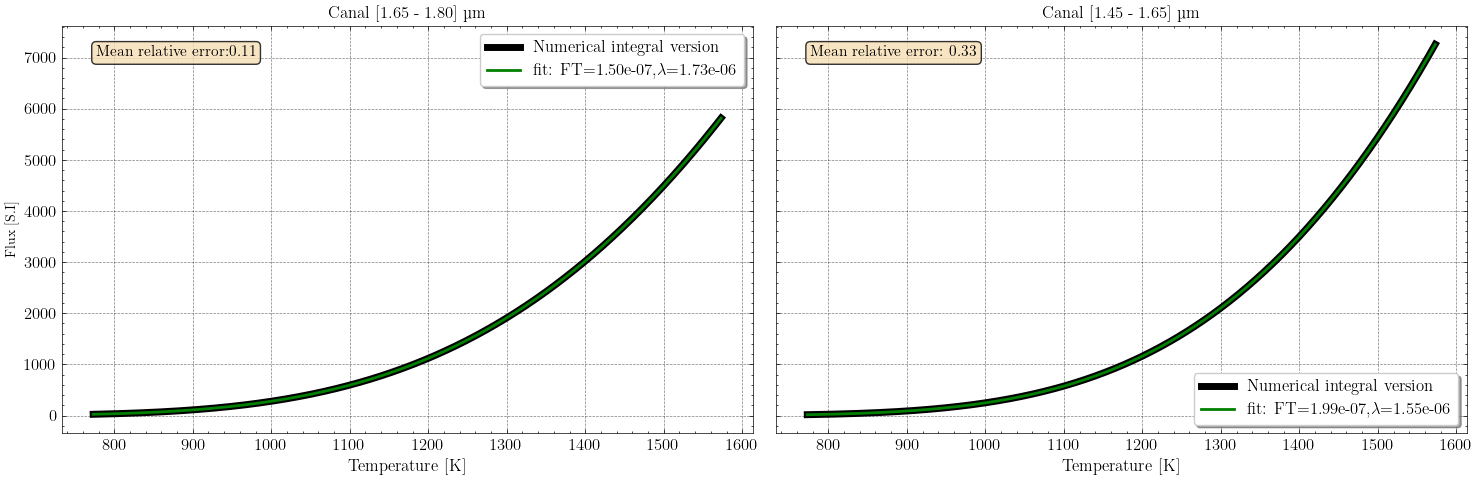

In [13]:
rel_error_1 = np.mean(np.abs((fluxIntegral_PYROMETER_ch1 - wien_law_equivalent(array_working_temperature_range, *popt_1)) / fluxIntegral_PYROMETER_ch1))
rel_error_2 = np.mean(np.abs((fluxIntegral_PYROMETER_ch2 - wien_law_equivalent(array_working_temperature_range, *popt_2)) / fluxIntegral_PYROMETER_ch2))

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 5), sharey=True)

## Channel 1
ax1.plot(
    array_working_temperature_range, fluxIntegral_PYROMETER_ch1, 
    c='k', lw=5, label='Numerical integral version'
    )
ax1.plot(
    array_working_temperature_range, wien_law_equivalent(array_working_temperature_range, *popt_1), 
    c='g', lw=2, label=f'fit: FT={popt_1[0]:.2e},'+r'$\lambda$' + f'={popt_1[1]:.2e}'
    )

rel_error_1 = np.mean(np.abs((fluxIntegral_PYROMETER_ch1 - wien_law_equivalent(array_working_temperature_range, *popt_1)) / fluxIntegral_PYROMETER_ch1))
text_str1 = f"Mean relative error:{rel_error_1:.2%}%"
ax1.text(
    0.05, 0.95, text_str1,
    transform=ax1.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
)

ax1.set_xlabel("Temperature [K]", fontsize=12)
ax1.set_ylabel(r"Flux [S.I]")
ax1.legend(loc='best', fontsize=12, frameon=True, shadow=True)
ax1.tick_params(axis='both', labelsize=12)
ax1.set_title('Canal [1.65 - 1.80] µm')
ax1.grid(True)

## Channel 2
ax2.plot(
    array_working_temperature_range, fluxIntegral_PYROMETER_ch2, 
    c='k', lw=5, label='Numerical integral version'
    )
ax2.plot(
    array_working_temperature_range, wien_law_equivalent(array_working_temperature_range, *popt_2), 
    c='g', lw=2, label=f'fit: FT={popt_2[0]:.2e},'+r'$\lambda$' + f'={popt_2[1]:.2e}'
    )
rel_error_2 = np.mean(np.abs((fluxIntegral_PYROMETER_ch2 - wien_law_equivalent(array_working_temperature_range, *popt_2)) / fluxIntegral_PYROMETER_ch2))
text_str2 = f"Mean relative error: {rel_error_2:.2%}%"
ax2.text(
    0.05, 0.95, text_str2,
    transform=ax2.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
)

ax2.set_xlabel("Temperature [K]", fontsize=12)
ax2.legend(loc='best', fontsize=12, frameon=True, shadow=True)
ax2.tick_params(axis='both', labelsize=12)
ax2.set_title('Canal [1.45 - 1.65] µm')
ax2.grid(True)

fig.tight_layout()
plt.show()

#### Planck's law vs Wien equivalent's law

In [14]:
array_planck_pyrometer_1 = np.zeros(len(array_working_temperature_range))
array_planck_pyrometer_2 = np.zeros(len(array_working_temperature_range))
array_wien_pyrometer_1 = np.zeros(len(array_working_temperature_range))
array_wien_pyrometer_2 = np.zeros(len(array_working_temperature_range))
array_wien_equivalent_pyrometer_1 = np.zeros(len(array_working_temperature_range))
array_wien_equivalent_pyrometer_2 = np.zeros(len(array_working_temperature_range))

for i, T in enumerate(array_working_temperature_range):
    array_planck_pyrometer_1[i] = integrate.quad(
        lambda l: planck_law(l, T), pyrometer_channel_1[0], pyrometer_channel_1[1])[0]
    array_planck_pyrometer_2[i] = integrate.quad(
        lambda l: planck_law(l, T), pyrometer_channel_2[0], pyrometer_channel_2[1])[0]
    array_wien_pyrometer_1[i] = integrate.quad(
        lambda l: wien_law(l, T), pyrometer_channel_1[0], pyrometer_channel_1[1])[0]
    array_wien_pyrometer_2[i] = integrate.quad(
        lambda l: wien_law(l, T), pyrometer_channel_2[0], pyrometer_channel_2[1])[0]
array_wien_equivalent_pyrometer_1 = wien_law_equivalent(array_working_temperature_range, *popt_1)
array_wien_equivalent_pyrometer_2 = wien_law_equivalent(array_working_temperature_range, *popt_2)

- $\xi_1(T) = \frac{|\varPhi_{\text{w,num}}(T) - \varPhi_{\text{p,num}}(T)|}{\varPhi_{\text{p,num}}(T)} \times 100$

- $\xi_2(T) = \frac{|\varPhi_{\text{w,eq}}(T) - \varPhi_{\text{p,num}}(T)|}{\varPhi_{\text{p,num}}(T)} \times 100$

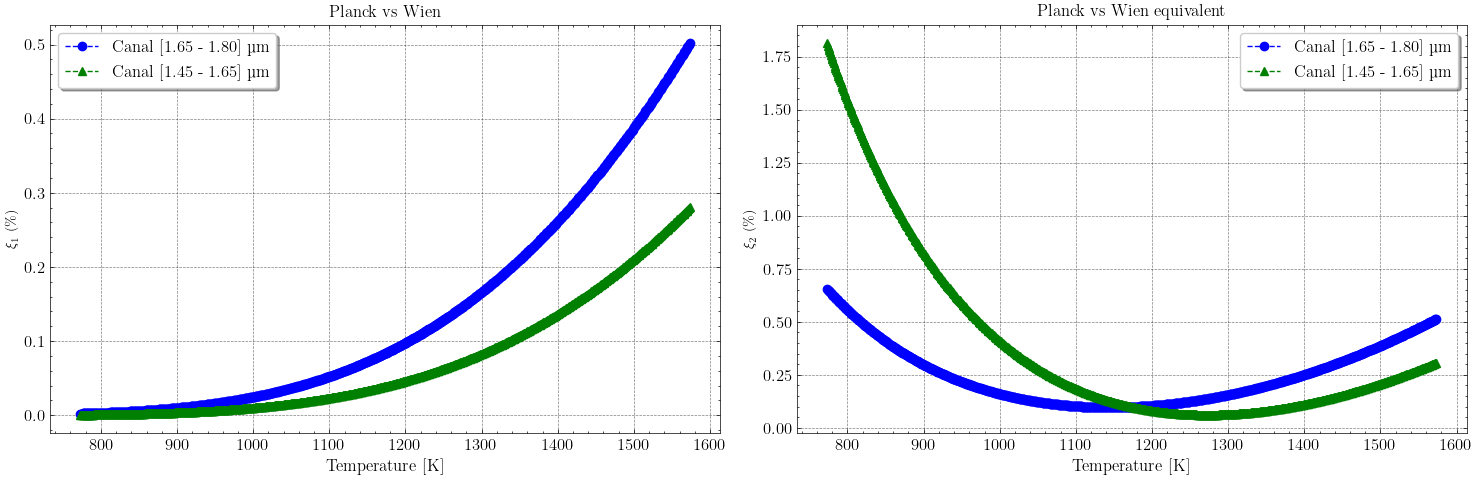

In [15]:
error_pyrometer_1 = 100*np.abs(array_planck_pyrometer_1 - array_wien_pyrometer_1)/array_planck_pyrometer_1
error_pyrometer_2 = 100*np.abs(array_planck_pyrometer_2 - array_wien_pyrometer_2)/array_planck_pyrometer_2
# 
error_eq_pyrometer_1 = 100*np.abs(array_planck_pyrometer_1 - array_wien_equivalent_pyrometer_1)/array_planck_pyrometer_1  # %
error_eq_pyrometer_2 = 100*np.abs(array_planck_pyrometer_2 - array_wien_equivalent_pyrometer_2)/array_planck_pyrometer_2  # %
#

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 5), sharex=True)

## First graph: Wien vs Planck
ax1.plot(array_working_temperature_range, error_pyrometer_1, 'bo--', label='Canal [1.65 - 1.80] µm')
ax1.plot(array_working_temperature_range, error_pyrometer_2, 'g^--', label='Canal [1.45 - 1.65] µm')
ax1.set_xlabel("Temperature [K]", fontsize=12)
ax1.set_ylabel(r"$\xi_1$ (\%)")
ax1.set_title("Planck vs Wien")
ax1.legend(loc='best', fontsize=12, frameon=True, shadow=True)
ax1.tick_params(axis='both', labelsize=12)
ax1.grid(True)

## Second graph: Wien equivalent vs Planck
ax2.plot(array_working_temperature_range, error_eq_pyrometer_1, 'bo--', label='Canal [1.65 - 1.80] µm')
ax2.plot(array_working_temperature_range, error_eq_pyrometer_2, 'g^--', label='Canal [1.45 - 1.65] µm')
ax2.set_xlabel("Temperature [K]", fontsize=12)
ax2.set_ylabel(r"$\xi_2$ (\%)")
ax2.set_title("Planck vs Wien equivalent")
ax2.legend(loc='best', fontsize=12, frameon=True, shadow=True)
ax2.tick_params(axis='both', labelsize=12)
ax2.grid(True)

fig.tight_layout()
plt.show()